In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('data(lab6).csv')

In [10]:
#15
df['log_price'] = df['log_price'].replace([float('inf'), float('-inf')], pd.NA)
q = df.groupby('col_7').agg({'col_7': 'count', 'col_2': 'mean', 'col_3': 'sum', 'log_price': 'mean'})
q.columns = ['count', 'mean_price', 'total_quantity', 'mean_log_price']
print(q.head())

KeyError: 'log_price'

In [11]:
#16
w = df.sort_values(by=['col_7', 'col_2'], ascending=True)
e = w.groupby('col_7').tail(1)
e = e[['col_1', 'col_2', 'col_7']]
print(e.sort_values(by='col_2', ascending=False))

            col_1  col_2        col_7
4318        Books    999        Books
9117         Home    999     Clothing
7576  Electronics    999  Electronics
8918  Electronics    999         Home
3230     Clothing    999       Sports


In [13]:
#17
df['total_value'] = df['col_2'] * df['col_3']
r = df.sort_values(by='total_value', ascending=False).head(10)
print(r[['col_1', 'col_2', 'col_3', 'total_value']])

            col_1  col_2  col_3  total_value
3833        Books    994    999       993006
4494       Sports    993    997       990021
9335     Clothing    994    992       986048
6431         Home    988    981       969228
3725  Electronics    997    971       968087
3389  Electronics    986    979       965294
3026  Electronics    997    968       965096
9202       Sports    966    996       962136
1380  Electronics    963    998       961074
3956     Clothing    982    975       957450


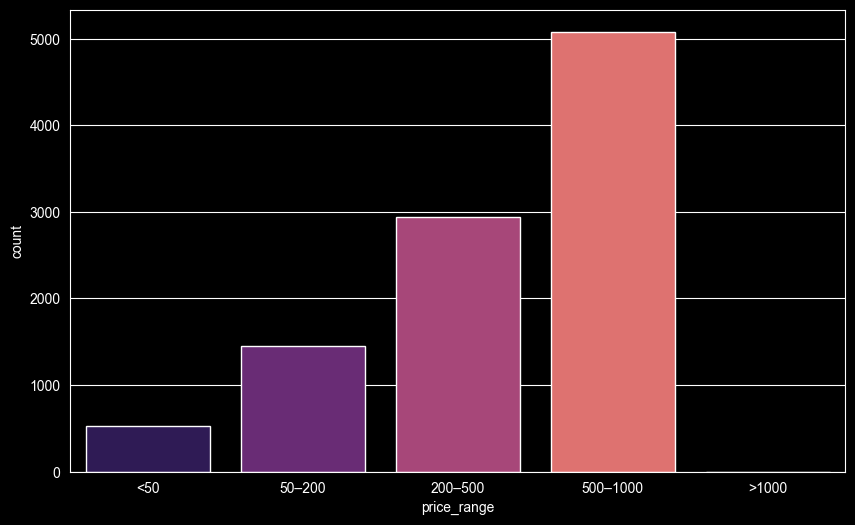

In [19]:
#18
bins = [0, 50, 200, 500, 1000, float('inf')]
labels = ['<50', '50–200', '200–500', '500–1000', '>1000']
df['price_range'] = pd.cut(df['col_2'], bins=bins, labels=labels, include_lowest=True)
a = df['price_range'].value_counts().reindex(labels).reset_index()
a.columns = ['price_range', 'count']
plt.figure(figsize=(10, 6))
sns.barplot(data=a, x='price_range', y='count', hue='price_range',  palette='magma', legend=False)
plt.show()

In [ ]:
#19


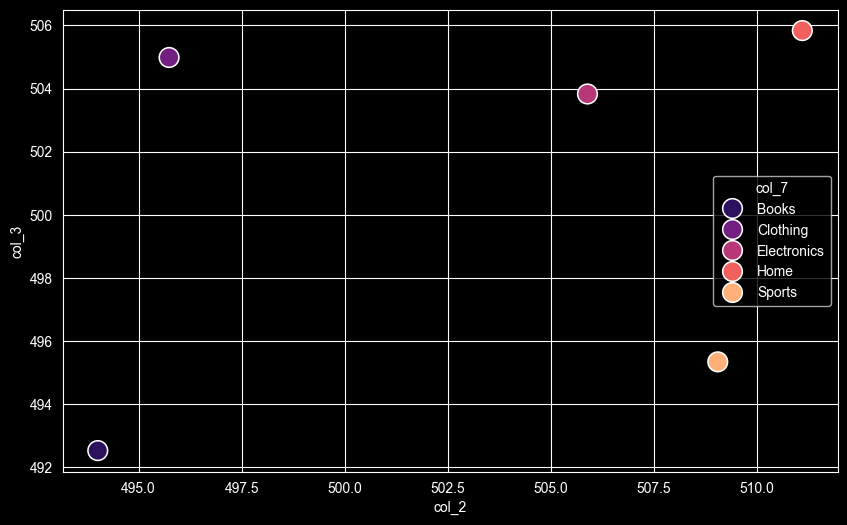

In [22]:
#20
t = df.groupby('col_7').agg({'col_2': 'mean', 'col_3': 'mean'}).reset_index()
plt.figure(figsize=(10, 6))
sns.scatterplot(data=t, x='col_2', y='col_3', hue='col_7', s=200, palette='magma')
plt.show()

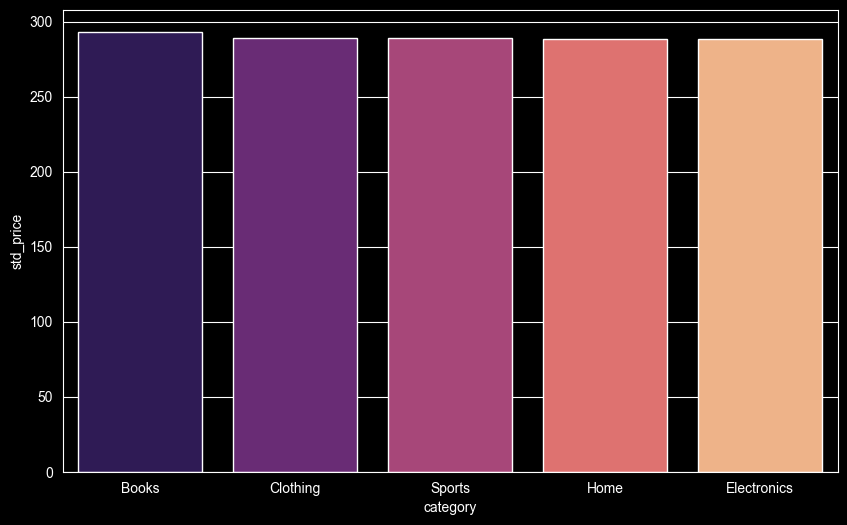

In [25]:
#21
u = df.groupby('col_7')['col_2'].std().reset_index()
u.columns = ['category', 'std_price']
u = u.sort_values(by='std_price', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=u, x='category', y='std_price', hue='category',  palette='magma', legend=False)
plt.show()